# Phase 3 — Feature Engineering Review
## EPL Over/Under 2.5 Goals Market · Football Market Intelligence System

---

**Purpose:** Audit the engineered feature matrix produced in Phase 3. Assess coverage, distribution, signal strength, and readiness for Phase 4 modelling.  
**Feature matrix:** `engineered_features` table (~1,900 rows × ~71 features)  
**Target variable:** `over_25` (1 = total goals > 2.5, 0 = total goals ≤ 2.5)  
**Data:** 5 EPL seasons (2019/20 – 2023/24) stored in DuckDB

### Notebook Sections
1. Data Overview  
2. Feature Coverage / NaN Analysis  
3. Rolling Form Feature Distributions  
4. Context Feature Distributions  
5. Market Feature Distributions  
6. Feature Correlation Analysis  
7. Bivariate Analysis: Features vs Over 2.5 Outcome  
8. Feature Engineering Quality Summary  
9. Key Findings

---
> All features use pre-match data only. No post-match statistics enter any computation.

In [10]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

from src.utils.db import run_query
from src.utils.config import DB_PATH

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE     = sns.color_palette('tab10')
SHARP_COL   = PALETTE[0]   # blue  — Pinnacle
REC_COL     = PALETTE[1]   # orange — Bet365
OVER_COL    = '#2ca02c'    # green — over 2.5
UNDER_COL   = '#d62728'    # red   — under 2.5

FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature group registry ─────────────────────────────────────────────────
FEATURE_GROUPS = {
    'Rolling 5-match': [
        'home_goals_scored_avg5', 'home_goals_conceded_avg5',
        'home_shots_avg5', 'home_shots_on_target_avg5',
        'home_wins_last5', 'home_clean_sheets_last5', 'home_over25_last5',
        'away_goals_scored_avg5', 'away_goals_conceded_avg5',
        'away_shots_avg5', 'away_shots_on_target_avg5',
        'away_wins_last5', 'away_clean_sheets_last5', 'away_over25_last5',
    ],
    'Rolling 3-match': [
        'home_goals_scored_avg3', 'home_goals_conceded_avg3',
        'away_goals_scored_avg3', 'away_goals_conceded_avg3',
    ],
    'xG 5-match': [
        'home_xg_for_avg5', 'home_xg_against_avg5',
        'away_xg_for_avg5', 'away_xg_against_avg5',
    ],
    'Derived': ['combined_goals_avg5', 'attack_proxy'],
    'Context': [
        'home_rest_days', 'away_rest_days', 'rest_differential',
        'home_matches_in_14_days', 'away_matches_in_14_days',
    ],
    'Elo': ['home_elo', 'away_elo', 'elo_differential'],
    'Market': [
        'pin_implied_prob_over', 'pin_odds_over', 'pin_odds_under', 'pin_margin',
        'b365_implied_prob_over', 'b365_odds_over', 'b365_odds_under', 'b365_margin',
        'avg_implied_prob_over', 'max_implied_prob_over', 'pin_b365_divergence',
        'opening_implied_prob_over', 'closing_implied_prob_over',
        'opening_margin', 'odds_movement_over',
    ],
}
ALL_FEATURE_COLS = [col for cols in FEATURE_GROUPS.values() for col in cols]

# ── Load complete feature matrix ───────────────────────────────────────────
SQL = '''
    SELECT
        ef.*,
        m.over_25,
        m.season,
        m.kickoff_utc
    FROM engineered_features ef
    JOIN matches m ON ef.match_id = m.match_id
    ORDER BY m.kickoff_utc
'''
df = run_query(SQL, db_path=DB_PATH)

# Coerce all feature columns to numeric
for col in ALL_FEATURE_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df['over_25'] = df['over_25'].astype(float)

# Summary
_n_feat_in_db = len([c for c in ALL_FEATURE_COLS if c in df.columns])
_n_over       = int(df['over_25'].sum())
_n_labelled   = int(df['over_25'].notna().sum())
_seasons      = sorted(df['season'].dropna().unique())
_kmin         = df['kickoff_utc'].min()
_kmax         = df['kickoff_utc'].max()

print(f'Feature matrix loaded  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Seasons                : {_seasons}')
print(f'Date range             : {_kmin} -> {_kmax}')
print(f'Over-2.5 base rate     : {df["over_25"].mean():.1%}  ({_n_over} / {_n_labelled} labelled matches)')
print(f'Features in registry   : {len(ALL_FEATURE_COLS)} defined  /  {_n_feat_in_db} present in DB')

Feature matrix loaded  : 1,900 rows x 57 columns
Seasons                : ['2019/20', '2020/21', '2021/22', '2022/23', '2023/24']
Date range             : 2019-08-09 20:00:00+01:00 -> 2024-05-19 16:00:00+01:00
Over-2.5 base rate     : 54.7%  (1039 / 1900 labelled matches)
Features in registry   : 47 defined  /  47 present in DB


---
## 1. Data Overview

In [11]:
# ── Season-level statistics ────────────────────────────────────────────────
print('=' * 65)
print('  FEATURE MATRIX — DATA OVERVIEW')
print('=' * 65)
print(f'  Total rows    : {df.shape[0]:,}')
print(f'  Total columns : {df.shape[1]}')
print(f'  Feature cols  : {_n_feat_in_db}  (of {len(ALL_FEATURE_COLS)} defined)')
print()

season_stats = (
    df.groupby('season', observed=True)
    .agg(
        matches=('match_id', 'count'),
        over25_n=('over_25', 'sum'),
        over25_rate=('over_25', 'mean')
    )
    .reset_index()
)
season_stats['Over-2.5 n']    = season_stats['over25_n'].astype(int)
season_stats = season_stats.rename(columns={'season': 'Season', 'matches': 'Matches', 'over25_rate': 'Over-2.5 Rate'})

print('Matches per season:')
display(
    season_stats[['Season', 'Matches', 'Over-2.5 n', 'Over-2.5 Rate']]
    .style
    .background_gradient(cmap='RdYlGn', subset=['Over-2.5 Rate'], vmin=0.45, vmax=0.70)
    .format({'Over-2.5 Rate': '{:.1%}'})
    .set_caption('Season-Level Summary')
    .hide(axis='index')
)
print()

# ── Feature group sizes ────────────────────────────────────────────────────
group_df = pd.DataFrame([
    {
        'Feature Group': g,
        'Defined': len(cols),
        'In DB': len([c for c in cols if c in df.columns]),
        'Example Features': ', '.join(cols[:2]),
    }
    for g, cols in FEATURE_GROUPS.items()
])
print('Feature group breakdown:')
display(
    group_df.style
    .set_caption('Feature Groups — Defined vs Available in DB')
    .hide(axis='index')
)
print()

# ── Dtype distribution ─────────────────────────────────────────────────────
feat_in_df    = [c for c in ALL_FEATURE_COLS if c in df.columns]
dtype_summary = df[feat_in_df].dtypes.astype(str).value_counts().reset_index()
dtype_summary.columns = ['dtype', 'count']
print('Dtype distribution across feature columns:')
display(dtype_summary.style.hide(axis='index'))
print()

# ── Preview ────────────────────────────────────────────────────────────────
prev_cols = ['match_id', 'home_goals_scored_avg5', 'combined_goals_avg5',
             'attack_proxy', 'home_elo', 'pin_implied_prob_over', 'over_25']
prev_cols = [c for c in prev_cols if c in df.columns]
fmt_map = {c: '{:.3f}' for c in prev_cols if c not in ('match_id', 'over_25', 'home_elo')}
if 'home_elo' in prev_cols:
    fmt_map['home_elo'] = '{:.0f}'

print('Feature matrix preview — first 5 rows (selected columns):')
display(
    df[prev_cols].head()
    .style
    .format(fmt_map)
    .background_gradient(
        cmap='Blues',
        subset=[c for c in ['pin_implied_prob_over'] if c in prev_cols]
    )
    .set_caption('Feature Matrix Preview')
)

  FEATURE MATRIX — DATA OVERVIEW
  Total rows    : 1,900
  Total columns : 57
  Feature cols  : 47  (of 47 defined)

Matches per season:


Season,Matches,Over-2.5 n,Over-2.5 Rate
2019/20,380,198,52.1%
2020/21,380,190,50.0%
2021/22,380,205,53.9%
2022/23,380,200,52.6%
2023/24,380,246,64.7%



Feature group breakdown:


Feature Group,Defined,In DB,Example Features
Rolling 5-match,14,14,"home_goals_scored_avg5, home_goals_conceded_avg5"
Rolling 3-match,4,4,"home_goals_scored_avg3, home_goals_conceded_avg3"
xG 5-match,4,4,"home_xg_for_avg5, home_xg_against_avg5"
Derived,2,2,"combined_goals_avg5, attack_proxy"
Context,5,5,"home_rest_days, away_rest_days"
Elo,3,3,"home_elo, away_elo"
Market,15,15,"pin_implied_prob_over, pin_odds_over"



Dtype distribution across feature columns:


dtype,count
float64,42
Int32,3
int32,2



Feature matrix preview — first 5 rows (selected columns):


,match_id,home_goals_scored_avg5,combined_goals_avg5,attack_proxy,home_elo,pin_implied_prob_over,over_25
0,EPL_201920_20190809_LIVNOR,nan,nan,nan,1500,0.690,1.000000
1,EPL_201920_20190810_WHUMCI,nan,nan,nan,1500,0.650,1.000000
2,EPL_201920_20190810_BURSOU,nan,nan,nan,1500,0.449,1.000000
3,EPL_201920_20190810_CRYEVE,nan,nan,nan,1500,0.438,0.000000
4,EPL_201920_20190810_WATBHA,nan,nan,nan,1500,0.446,1.000000


---
## 2. Feature Coverage / NaN Analysis

Coverage is defined as the fraction of non-null values per feature.  
Expected patterns:
- **Rolling 5-match features**: first 4 matches of each team-season have NaN (insufficient history) → ~89–92% coverage.
- **Rolling 3-match features**: first 2 matches → slightly higher coverage than 5-match.
- **xG 5-match features**: ~99.3% coverage — populated from Understat (Phase 4b ingestion). The ~0.7% NaN fraction corresponds to early-season matches where the rolling xG window could not be computed.
- **Market features**: near 100%, except where a bookmaker had no line for a specific match.

Features with 100% coverage : 8
Features with partial coverage: 39
Features with 0% coverage   : 0


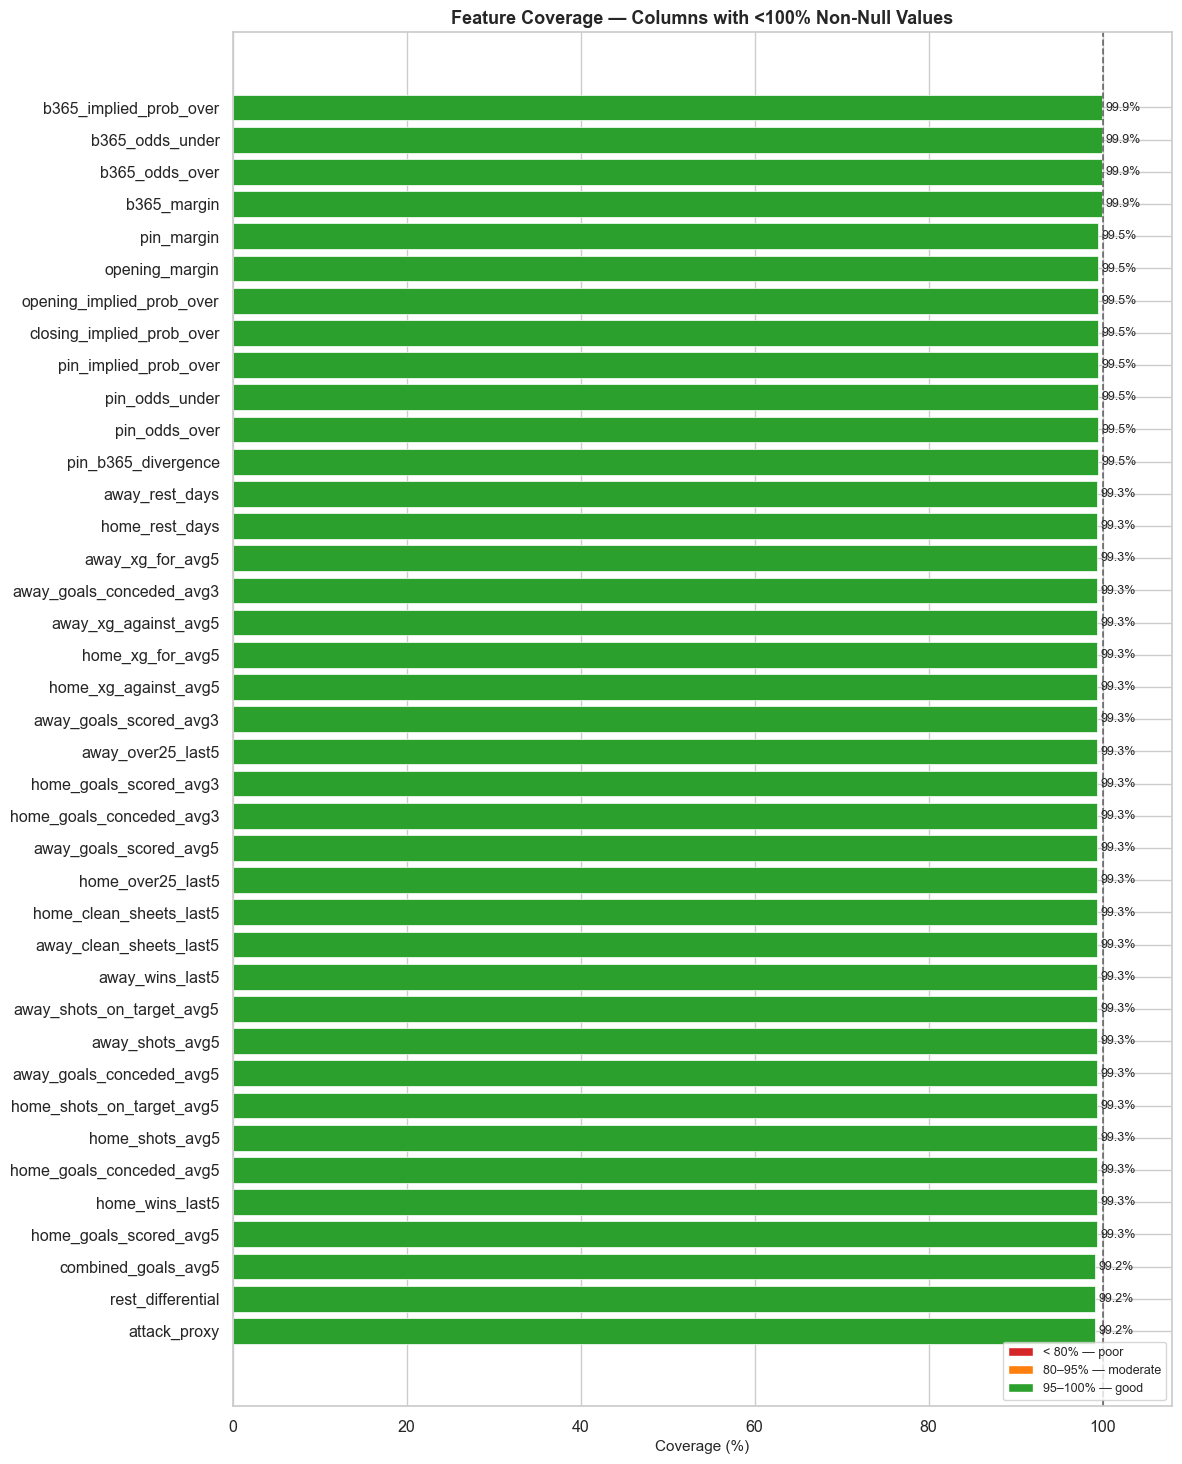

Saved: 03_feature_coverage.png

Coverage by feature group:


Feature Group,# Defined,# In DB,Min Coverage (%),Avg Coverage (%)
Elo,3,3,100.0,100.0
Market,15,15,99.5,99.7
Context,5,5,99.2,99.6
xG 5-match,4,4,99.3,99.3
Rolling 3-match,4,4,99.3,99.3
Rolling 5-match,14,14,99.3,99.3
Derived,2,2,99.2,99.2



Interpretation:
  Rolling features show partial coverage for the opening matches of each
  team-season — expected when the window (5 or 3 games) exceeds history.
  These rows can be dropped or imputed before modelling.
  Market features near 100% confirms the odds scraping pipeline was reliable.


In [12]:
# ── Compute per-column coverage ─────────────────────────────────────────────
avail_cols = [c for c in ALL_FEATURE_COLS if c in df.columns]
coverage   = (df[avail_cols].notna().mean() * 100).sort_values(ascending=True)
partial    = coverage[coverage < 99.95]   # anything not perfectly 100%

print(f'Features with 100% coverage : {(coverage >= 99.95).sum()}')
print(f'Features with partial coverage: {len(partial)}')
print(f'Features with 0% coverage   : {(coverage == 0).sum()}')

# ── Bar chart: partial-coverage features ──────────────────────────────────
if len(partial) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(partial) * 0.38)))
    bar_colors = ['#d62728' if v < 80 else '#ff7f0e' if v < 95 else '#2ca02c'
                  for v in partial.values]
    bars = ax.barh(partial.index, partial.values, color=bar_colors,
                   edgecolor='white', linewidth=0.5)
    ax.axvline(100, color='#333333', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_xlabel('Coverage (%)', fontsize=11)
    ax.set_title('Feature Coverage — Columns with <100% Non-Null Values',
                 fontsize=13, fontweight='bold')
    ax.set_xlim(0, 108)
    for bar, val in zip(bars, partial.values):
        ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d62728', label='< 80% — poor'),
        Patch(facecolor='#ff7f0e', label='80–95% — moderate'),
        Patch(facecolor='#2ca02c', label='95–100% — good'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_feature_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_feature_coverage.png')
else:
    print('All features present in DB have 100% coverage.')

# ── Coverage by feature group ──────────────────────────────────────────────
group_cov_rows = []
for group, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in df.columns]
    if present:
        avg_cov = df[present].notna().mean().mean() * 100
        min_cov = df[present].notna().mean().min() * 100
        group_cov_rows.append({
            'Feature Group': group,
            '# Defined': len(cols),
            '# In DB': len(present),
            'Min Coverage (%)': round(min_cov, 1),
            'Avg Coverage (%)': round(avg_cov, 1),
        })

cov_df = pd.DataFrame(group_cov_rows).sort_values('Avg Coverage (%)', ascending=False)
print('\nCoverage by feature group:')
display(
    cov_df.style
    .background_gradient(cmap='RdYlGn', subset=['Avg Coverage (%)', 'Min Coverage (%)'],
                         vmin=0, vmax=100)
    .format({'Min Coverage (%)': '{:.1f}', 'Avg Coverage (%)': '{:.1f}'})
    .set_caption('Feature Group Coverage Summary')
    .hide(axis='index')
)

print('\nInterpretation:')
print('  Rolling features show partial coverage for the opening matches of each')
print('  team-season — expected when the window (5 or 3 games) exceeds history.')
print('  These rows can be dropped or imputed before modelling.')
print('  Market features near 100% confirms the odds scraping pipeline was reliable.')

---
## 3. Rolling Form Feature Distributions

Rolling averages over the last 3 or 5 matches capture a team's recent form.  
Key questions:
- Do distributions look plausible (bounded, unimodal)?
- Do `combined_goals_avg5` and `attack_proxy` separate over/under outcomes?

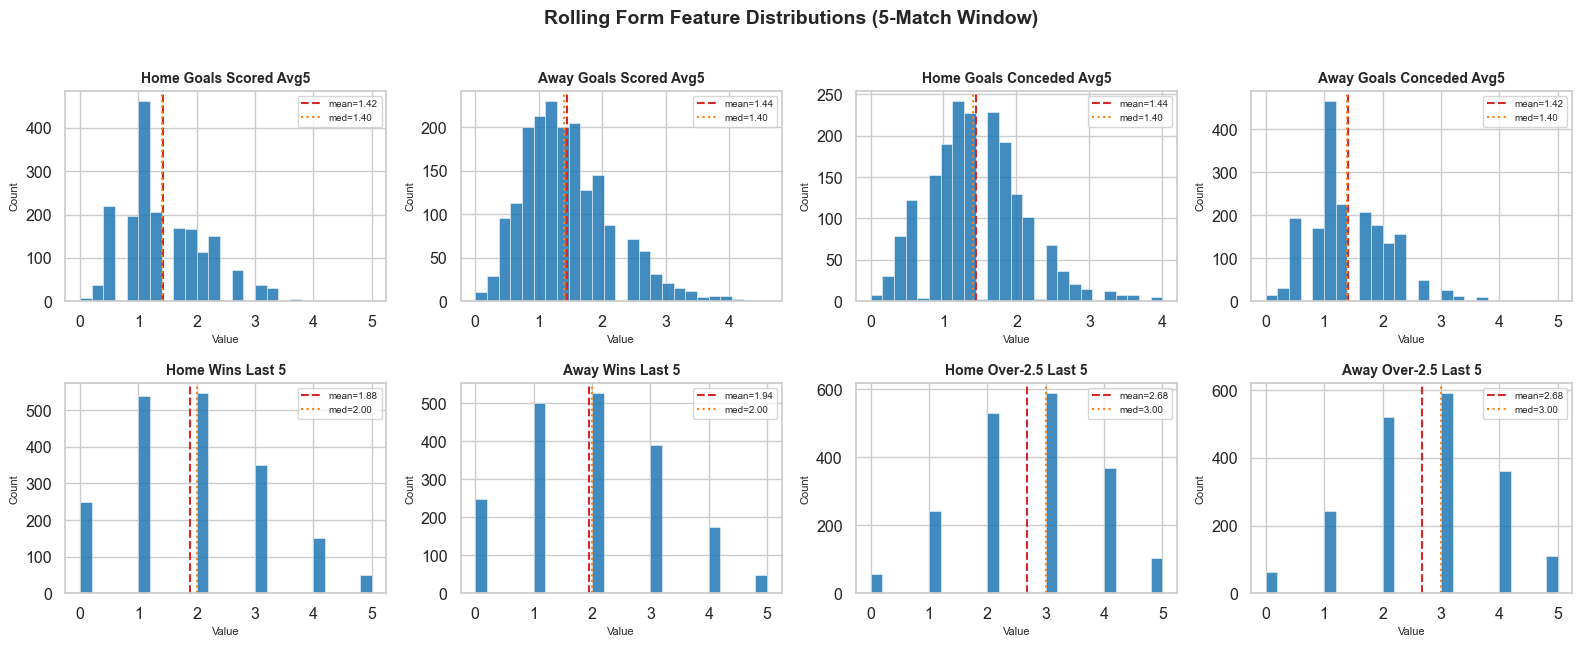

Saved: 03_rolling_histograms.png


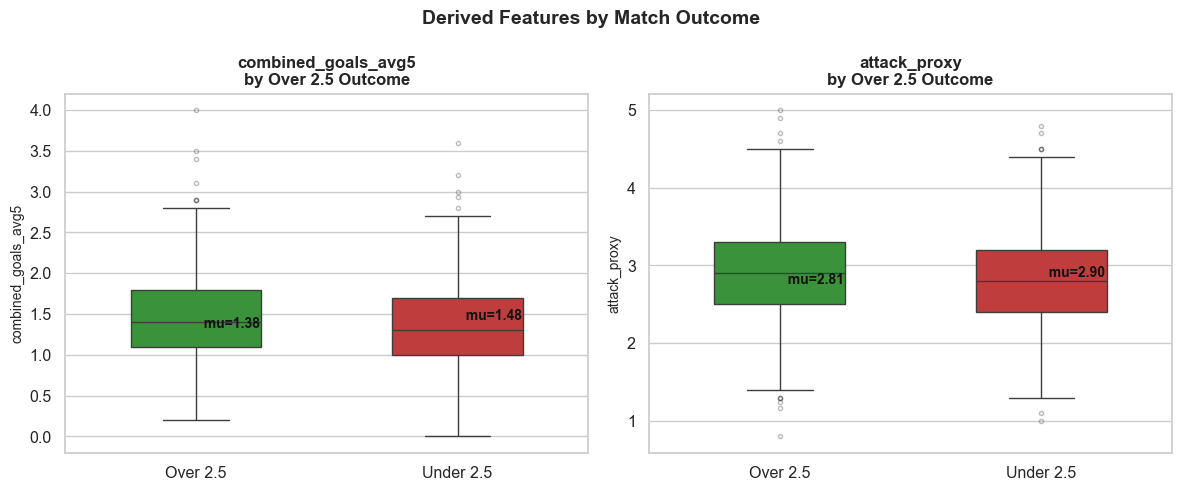

Saved: 03_derived_boxplot.png

Attack Proxy insight (split at median = 2.80):
  Low attack_proxy  (<median) -> Over 2.5 rate : 50.4%
  High attack_proxy (>=median) -> Over 2.5 rate: 57.9%
  Lift (high vs low)           : +7.5 pp


In [13]:
# ── Histogram grid: core rolling form features ─────────────────────────────
hist_specs = [
    ('home_goals_scored_avg5',   'Home Goals Scored Avg5'),
    ('away_goals_scored_avg5',   'Away Goals Scored Avg5'),
    ('home_goals_conceded_avg5', 'Home Goals Conceded Avg5'),
    ('away_goals_conceded_avg5', 'Away Goals Conceded Avg5'),
    ('home_wins_last5',          'Home Wins Last 5'),
    ('away_wins_last5',          'Away Wins Last 5'),
    ('home_over25_last5',        'Home Over-2.5 Last 5'),
    ('away_over25_last5',        'Away Over-2.5 Last 5'),
]
hist_specs = [(c, lbl) for c, lbl in hist_specs if c in df.columns]

n_cols = 4
n_rows = (len(hist_specs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for idx, (col, label) in enumerate(hist_specs):
    ax  = axes[idx]
    dat = df[col].dropna()
    if dat.empty:
        ax.text(0.5, 0.5, f"{label}(no data)", ha='center', va='center', transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_title(label, fontsize=10, fontweight='bold')
        continue
    ax.hist(dat, bins=25, color=SHARP_COL, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(dat.mean(), color=UNDER_COL, linestyle='--', linewidth=1.5,
               label=f'mean={dat.mean():.2f}')
    ax.axvline(dat.median(), color='#ff7f0e', linestyle=':', linewidth=1.5,
               label=f'med={dat.median():.2f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')

for idx in range(len(hist_specs), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Rolling Form Feature Distributions (5-Match Window)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_rolling_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_rolling_histograms.png')

# ── Box plots: combined_goals_avg5 and attack_proxy by outcome ─────────────
box_targets = [c for c in ['combined_goals_avg5', 'attack_proxy'] if c in df.columns]
plot_df = df[box_targets + ['over_25']].dropna(subset=['over_25'])
plot_df = plot_df.copy()
plot_df['Outcome'] = plot_df['over_25'].map({0.0: 'Under 2.5', 1.0: 'Over 2.5'})
outcome_palette = {'Under 2.5': UNDER_COL, 'Over 2.5': OVER_COL}

fig, axes = plt.subplots(1, len(box_targets), figsize=(6 * len(box_targets), 5))
if len(box_targets) == 1:
    axes = [axes]

for ax, col in zip(axes, box_targets):
    sub = plot_df[['Outcome', col]].dropna()
    sns.boxplot(data=sub, x='Outcome', y=col, palette=outcome_palette, ax=ax,
                width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.35))
    means = sub.groupby('Outcome')[col].mean()
    for i, outcome in enumerate(['Under 2.5', 'Over 2.5']):
        if outcome in means.index:
            ax.text(i, means[outcome], f'  mu={means[outcome]:.2f}',
                    ha='left', va='center', fontsize=10, fontweight='bold',
                    color='#111111')
    ax.set_title(f'{col}\nby Over 2.5 Outcome', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=10)

fig.suptitle('Derived Features by Match Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_derived_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_derived_boxplot.png')

# ── Attack proxy insight ───────────────────────────────────────────────────
if 'attack_proxy' in df.columns:
    ap    = df[['attack_proxy', 'over_25']].dropna()
    med   = ap['attack_proxy'].median()
    low_r  = ap.loc[ap['attack_proxy'] <  med, 'over_25'].mean()
    high_r = ap.loc[ap['attack_proxy'] >= med, 'over_25'].mean()
    print(f'\nAttack Proxy insight (split at median = {med:.2f}):')
    print(f'  Low attack_proxy  (<median) -> Over 2.5 rate : {low_r:.1%}')
    print(f'  High attack_proxy (>=median) -> Over 2.5 rate: {high_r:.1%}')
    print(f'  Lift (high vs low)           : +{(high_r - low_r)*100:.1f} pp')

---
## 4. Context Feature Distributions

Context features capture match scheduling effects — rest time, fixture congestion, and relative team strength (Elo).  
Expected findings:
- Most EPL teams have 4–10 rest days between matches; congested periods (Champions League sides) push this lower.
- Elo ratings should be roughly normally distributed around 1500 (the Elo base).
- Elo differential is a proxy for mismatch strength — large differentials tend toward fewer goals (defensive setup by weaker side).

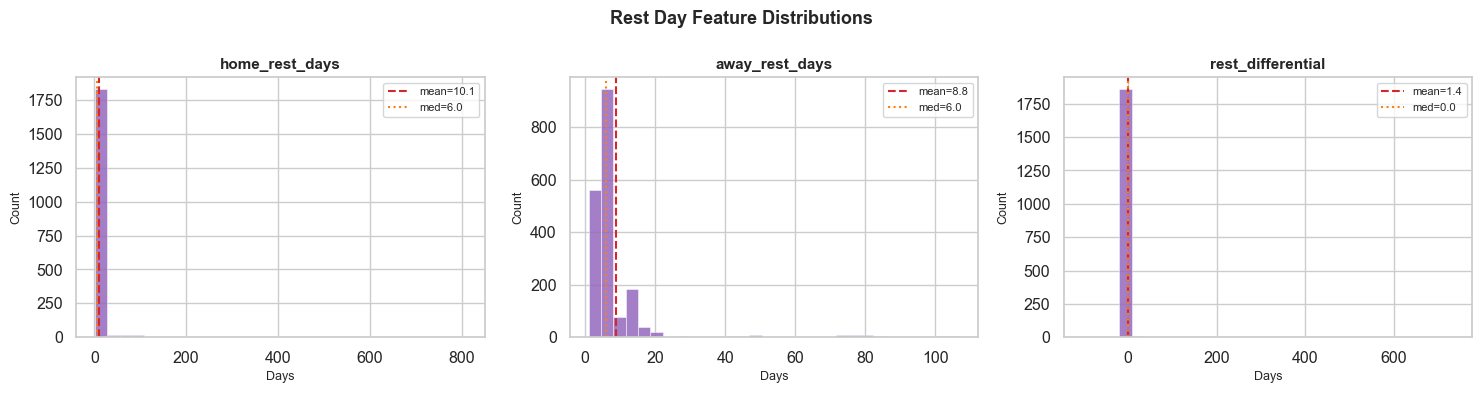

Saved: 03_rest_days.png


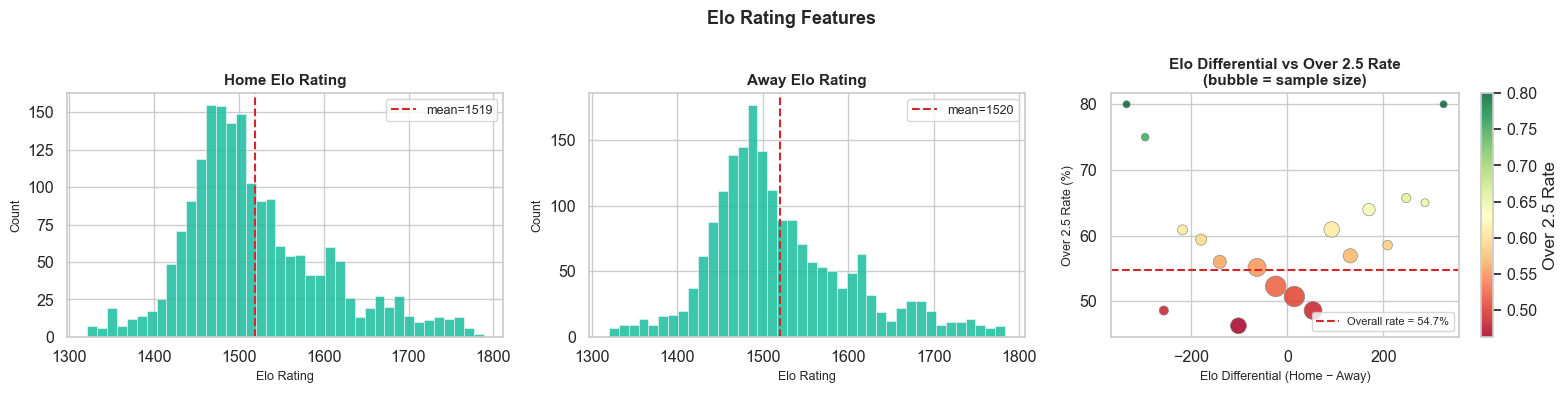

Saved: 03_elo_features.png


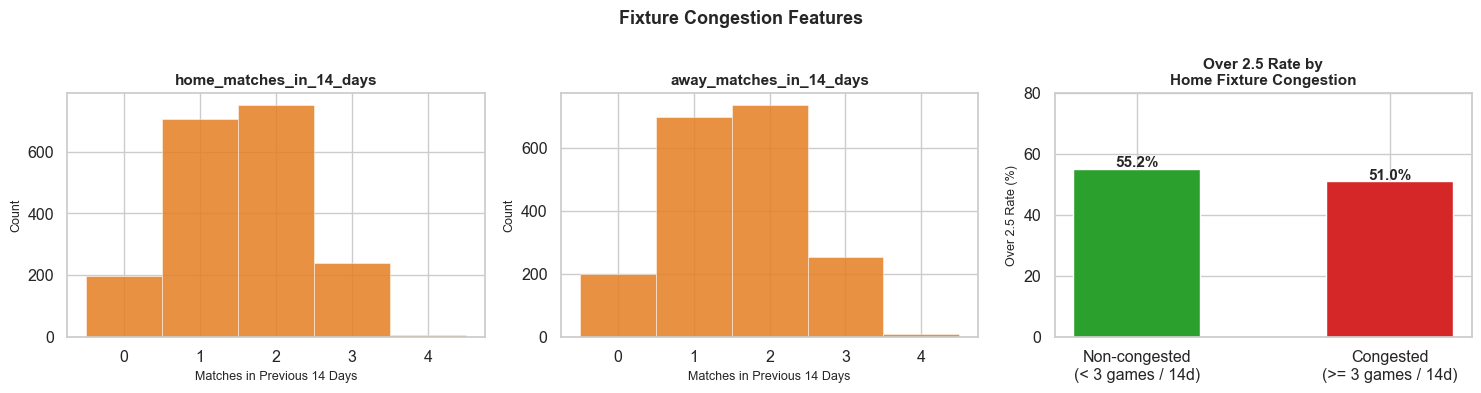

Saved: 03_congestion.png

Context + Elo — Average Feature Value by Outcome:


Feature,Under 2.5 (mean),Over 2.5 (mean),Delta (Over - Under)
home_rest_days,10.26,10.05,-0.21
away_rest_days,8.66,8.83,+0.16
rest_differential,1.61,1.20,-0.41
home_matches_in_14_days,1.58,1.53,-0.05
away_matches_in_14_days,1.57,1.56,-0.01
home_elo,1511.57,1525.14,+13.57
away_elo,1517.30,1522.39,+5.09
elo_differential,-5.74,2.74,+8.48


In [14]:
# ── Rest days histograms ────────────────────────────────────────────────────
rest_cols = [c for c in ['home_rest_days', 'away_rest_days', 'rest_differential']
             if c in df.columns]

if rest_cols:
    fig, axes = plt.subplots(1, len(rest_cols), figsize=(5 * len(rest_cols), 4))
    if len(rest_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, rest_cols):
        dat = df[col].dropna()
        ax.hist(dat, bins=30, color='#9467bd', edgecolor='white', linewidth=0.4, alpha=0.85)
        ax.axvline(dat.mean(),   color=UNDER_COL, linestyle='--', linewidth=1.5,
                   label=f'mean={dat.mean():.1f}')
        ax.axvline(dat.median(), color='#ff7f0e', linestyle=':',  linewidth=1.5,
                   label=f'med={dat.median():.1f}')
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Days', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.legend(fontsize=8)
    fig.suptitle('Rest Day Feature Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_rest_days.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_rest_days.png')

# ── Elo: distributions + differential vs over_25 rate ─────────────────────
elo_home_col = 'home_elo' if 'home_elo' in df.columns else None
elo_away_col = 'away_elo' if 'away_elo' in df.columns else None
elo_diff_col = 'elo_differential' if 'elo_differential' in df.columns else None

if elo_home_col or elo_diff_col:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, col, title in zip(axes[:2],
                               [elo_home_col, elo_away_col],
                               ['Home Elo Rating', 'Away Elo Rating']):
        if col and col in df.columns:
            dat = df[col].dropna()
            ax.hist(dat, bins=40, color='#1abc9c', edgecolor='white', linewidth=0.4, alpha=0.85)
            ax.axvline(dat.mean(), color=UNDER_COL, linestyle='--', linewidth=1.5,
                       label=f'mean={dat.mean():.0f}')
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xlabel('Elo Rating', fontsize=9)
            ax.set_ylabel('Count', fontsize=9)
            ax.legend(fontsize=9)
        else:
            ax.set_visible(False)

    if elo_diff_col:
        ax = axes[2]
        elo_df = df[[elo_diff_col, 'over_25']].dropna()
        elo_df = elo_df.copy()
        elo_df['elo_bin'] = pd.cut(elo_df[elo_diff_col], bins=20)
        bin_stats = (
            elo_df.groupby('elo_bin', observed=True)
            .agg(over25_rate=('over_25', 'mean'), n=('over_25', 'count'))
            .reset_index()
        )
        bin_stats = bin_stats[bin_stats['n'] >= 10]
        bin_mid   = bin_stats['elo_bin'].apply(lambda x: x.mid).astype(float)
        sc = ax.scatter(bin_mid, bin_stats['over25_rate'] * 100,
                        s=bin_stats['n'] / bin_stats['n'].max() * 200 + 20,
                        c=bin_stats['over25_rate'], cmap='RdYlGn',
                        alpha=0.85, edgecolors='grey', linewidths=0.5)
        overall = df['over_25'].mean()
        ax.axhline(overall * 100, color=UNDER_COL, linestyle='--', linewidth=1.5,
                   label=f'Overall rate = {overall:.1%}')
        ax.set_xlabel('Elo Differential (Home − Away)', fontsize=9)
        ax.set_ylabel('Over 2.5 Rate (%)', fontsize=9)
        ax.set_title('Elo Differential vs Over 2.5 Rate\n(bubble = sample size)', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        plt.colorbar(sc, ax=ax, label='Over 2.5 Rate')

    fig.suptitle('Elo Rating Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_elo_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_elo_features.png')

# ── Fixture congestion ─────────────────────────────────────────────────────
cong_cols = [c for c in ['home_matches_in_14_days', 'away_matches_in_14_days']
             if c in df.columns]

if cong_cols:
    fig, axes = plt.subplots(1, len(cong_cols) + 1, figsize=(5 * (len(cong_cols) + 1), 4))

    for i, col in enumerate(cong_cols):
        dat = df[col].dropna()
        bins = np.arange(dat.min() - 0.5, dat.max() + 1.5, 1)
        axes[i].hist(dat, bins=bins, color='#e67e22', edgecolor='white', linewidth=0.4, alpha=0.85)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Matches in Previous 14 Days', fontsize=9)
        axes[i].set_ylabel('Count', fontsize=9)
        axes[i].xaxis.set_major_locator(mticker.MultipleLocator(1))

    ax = axes[-1]
    if 'home_matches_in_14_days' in df.columns:
        cong_sub = df[['home_matches_in_14_days', 'over_25']].dropna()
        cong_sub = cong_sub.copy()
        cong_sub['congested'] = cong_sub['home_matches_in_14_days'] >= 3
        cong_rates = cong_sub.groupby('congested')['over_25'].mean()
        labels = ['Non-congested\n(< 3 games / 14d)', 'Congested\n(>= 3 games / 14d)']
        vals   = [cong_rates.get(False, np.nan), cong_rates.get(True, np.nan)]
        colors = [OVER_COL, UNDER_COL]
        bars   = ax.bar(labels, [v * 100 if not np.isnan(v) else 0 for v in vals],
                        color=colors, width=0.5, edgecolor='white')
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
        ax.set_ylabel('Over 2.5 Rate (%)', fontsize=9)
        ax.set_title('Over 2.5 Rate by\nHome Fixture Congestion', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 80)

    fig.suptitle('Fixture Congestion Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_congestion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_congestion.png')

# ── Table: avg feature values by outcome ──────────────────────────────────
context_all = (
    [c for c in ['home_rest_days', 'away_rest_days', 'rest_differential',
                 'home_matches_in_14_days', 'away_matches_in_14_days',
                 'home_elo', 'away_elo', 'elo_differential']
     if c in df.columns]
)
if context_all:
    sub = df[context_all + ['over_25']].dropna(subset=['over_25'])
    outcome_tbl = (
        sub.groupby('over_25')[context_all]
        .mean()
        .T
        .rename(columns={0.0: 'Under 2.5 (mean)', 1.0: 'Over 2.5 (mean)'})
        .reset_index()
        .rename(columns={'index': 'Feature'})
    )
    outcome_tbl['Delta (Over - Under)'] = (
        outcome_tbl['Over 2.5 (mean)'] - outcome_tbl['Under 2.5 (mean)']
    )
    print('\nContext + Elo — Average Feature Value by Outcome:')
    display(
        outcome_tbl.style
        .format({
            'Under 2.5 (mean)': '{:.2f}',
            'Over 2.5 (mean)': '{:.2f}',
            'Delta (Over - Under)': '{:+.2f}',
        })
        .background_gradient(cmap='RdBu_r', subset=['Delta (Over - Under)'])
        .set_caption('Context Feature Means by Outcome')
        .hide(axis='index')
    )

---
## 5. Market Feature Distributions

Market features encode pre-match bookmaker opinion.  
Pinnacle (sharp) prices reflect the sharpest consensus; Bet365 (recreational) can diverge.  

Key checks:
- Is Pinnacle's implied probability distribution centred around the actual over-2.5 base rate (~54.5%)?
- How tightly do Pinnacle and Bet365 agree?
- Does high bookmaker divergence correlate with a different outcome rate?

PIN vs B365 Pearson r = 0.9713  -> near-perfect linear agreement


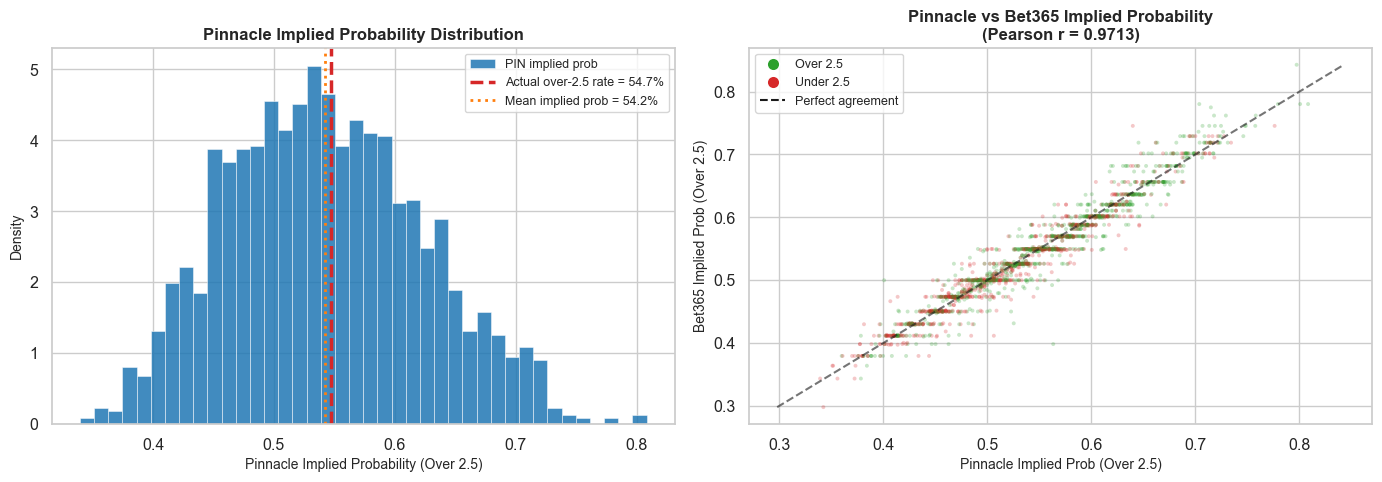

Saved: 03_market_prob.png


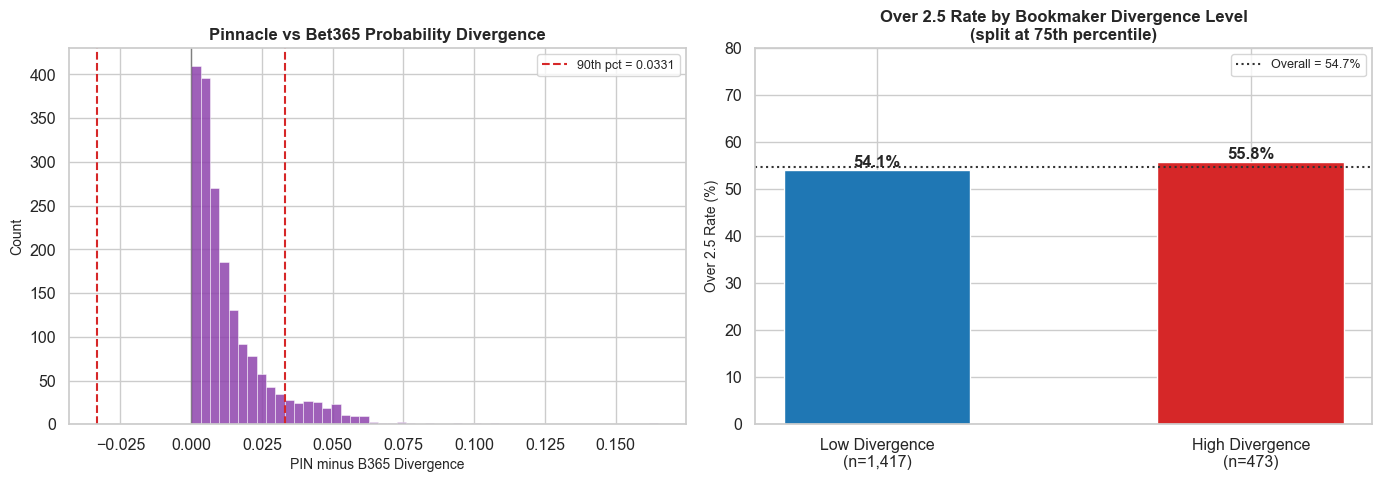

Saved: 03_divergence.png

Divergence summary:
  Mean |PIN-B365|        : 1.335 pp
  90th pct |divergence|  : 3.314 pp
  Low-divergence rate    : 54.1%
  High-divergence rate   : 55.8%
  Delta                  : +1.7 pp


In [15]:
# ── Pinnacle implied prob histogram + actual rate overlay ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
if 'pin_implied_prob_over' in df.columns:
    dat         = df['pin_implied_prob_over'].dropna()
    actual_rate = df['over_25'].mean()
    ax.hist(dat, bins=40, color=SHARP_COL, edgecolor='white', linewidth=0.4,
            alpha=0.85, density=True, label='PIN implied prob')
    ax.axvline(actual_rate, color=UNDER_COL, linestyle='--', linewidth=2.5,
               label=f'Actual over-2.5 rate = {actual_rate:.1%}')
    ax.axvline(dat.mean(), color='#ff7f0e', linestyle=':', linewidth=2.0,
               label=f'Mean implied prob = {dat.mean():.1%}')
    ax.set_xlabel('Pinnacle Implied Probability (Over 2.5)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title('Pinnacle Implied Probability Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'pin_implied_prob_over not found', ha='center', transform=ax.transAxes)

# ── PIN vs B365 implied prob scatter, coloured by outcome ─────────────────
ax = axes[1]
pin_col  = 'pin_implied_prob_over'
b365_col = 'b365_implied_prob_over'
if pin_col in df.columns and b365_col in df.columns:
    scat_df = df[[pin_col, b365_col, 'over_25']].dropna()
    c_vals  = scat_df['over_25'].map({0.0: UNDER_COL, 1.0: OVER_COL})
    ax.scatter(scat_df[pin_col], scat_df[b365_col], c=c_vals,
               alpha=0.25, s=8, linewidths=0)
    lo = min(scat_df[pin_col].min(), scat_df[b365_col].min())
    hi = max(scat_df[pin_col].max(), scat_df[b365_col].max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, alpha=0.6, label='Perfect agreement')
    r_val = scat_df[pin_col].corr(scat_df[b365_col])
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=OVER_COL,
               markersize=9, label='Over 2.5'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=UNDER_COL,
               markersize=9, label='Under 2.5'),
        Line2D([0], [0], color='k', linestyle='--', linewidth=1.5, label='Perfect agreement'),
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    ax.set_xlabel('Pinnacle Implied Prob (Over 2.5)', fontsize=10)
    ax.set_ylabel('Bet365 Implied Prob (Over 2.5)', fontsize=10)
    ax.set_title(f'Pinnacle vs Bet365 Implied Probability\n(Pearson r = {r_val:.4f})',
                 fontsize=12, fontweight='bold')
    print(f'PIN vs B365 Pearson r = {r_val:.4f}  -> near-perfect linear agreement')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_market_prob.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_market_prob.png')

# ── Pin-B365 divergence analysis ───────────────────────────────────────────
if 'pin_b365_divergence' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax  = axes[0]
    div = df['pin_b365_divergence'].dropna()
    q90 = div.abs().quantile(0.90)
    ax.hist(div, bins=50, color='#8e44ad', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline( q90, color=UNDER_COL, linestyle='--', linewidth=1.5,
               label=f'90th pct = {q90:.4f}')
    ax.axvline(-q90, color=UNDER_COL, linestyle='--', linewidth=1.5)
    ax.axvline(0, color='#333333', linewidth=1.0, alpha=0.5)
    ax.set_xlabel('PIN minus B365 Divergence', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('Pinnacle vs Bet365 Probability Divergence', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    ax = axes[1]
    div_df    = df[['pin_b365_divergence', 'over_25']].dropna()
    threshold = div_df['pin_b365_divergence'].abs().quantile(0.75)
    low_mask  = div_df['pin_b365_divergence'].abs() <  threshold
    high_mask = div_df['pin_b365_divergence'].abs() >= threshold
    low_rate  = div_df.loc[low_mask,  'over_25'].mean()
    high_rate = div_df.loc[high_mask, 'over_25'].mean()
    low_n     = low_mask.sum()
    high_n    = high_mask.sum()
    labels    = [f'Low Divergence\n(n={low_n:,})', f'High Divergence\n(n={high_n:,})']
    rates     = [low_rate, high_rate]
    bars      = ax.bar(labels, [v * 100 for v in rates],
                       color=[SHARP_COL, UNDER_COL], width=0.5, edgecolor='white')
    for bar, val in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
    overall = df['over_25'].mean()
    ax.axhline(overall * 100, color='#333333', linestyle=':', linewidth=1.5,
               label=f'Overall = {overall:.1%}')
    ax.set_ylabel('Over 2.5 Rate (%)', fontsize=10)
    ax.set_title('Over 2.5 Rate by Bookmaker Divergence Level\n(split at 75th percentile)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 80)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_divergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_divergence.png')

    print(f'\nDivergence summary:')
    print(f'  Mean |PIN-B365|        : {div_df["pin_b365_divergence"].abs().mean()*100:.3f} pp')
    print(f'  90th pct |divergence|  : {q90*100:.3f} pp')
    print(f'  Low-divergence rate    : {low_rate:.1%}')
    print(f'  High-divergence rate   : {high_rate:.1%}')
    print(f'  Delta                  : {(high_rate-low_rate)*100:+.1f} pp')

---
## 6. Feature Correlation Analysis

Pearson correlation against the binary target `over_25` gives a first-pass linear signal estimate.  
Expected findings:
- **Market features** (implied probabilities) will dominate — they are engineered summaries of all public information.
- **Rolling form** features provide incremental signal beyond market.
- **Context/Elo** features provide weak but orthogonal signal.
- `pin_implied_prob_over` and `b365_implied_prob_over` will be nearly perfectly collinear (r > 0.97).

Features eligible for correlation analysis : 47
Rows after dropping unlabelled target rows  : 1,900


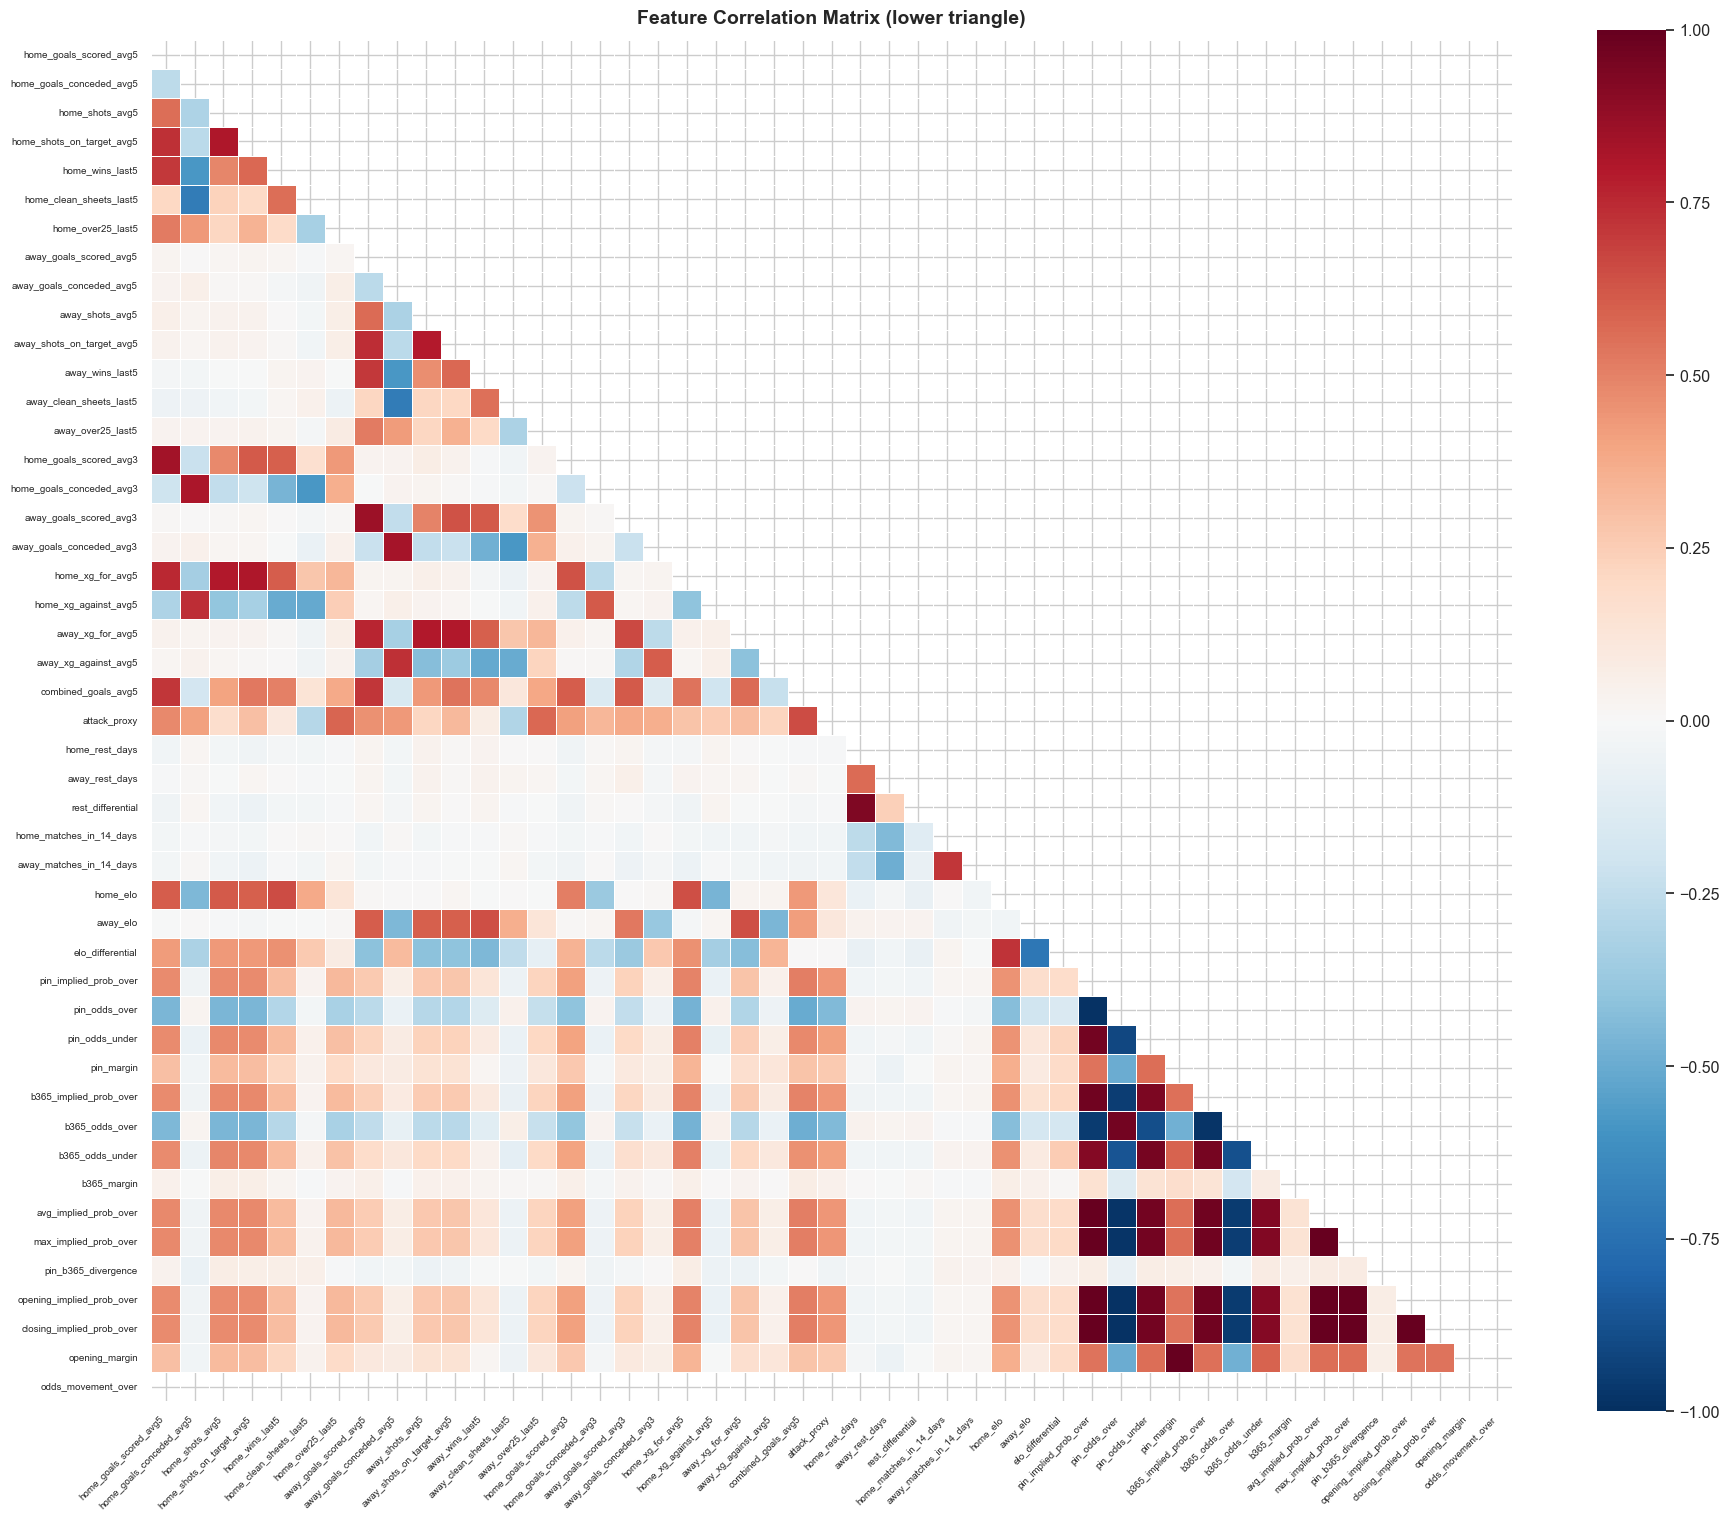

Saved: 03_correlation_heatmap.png


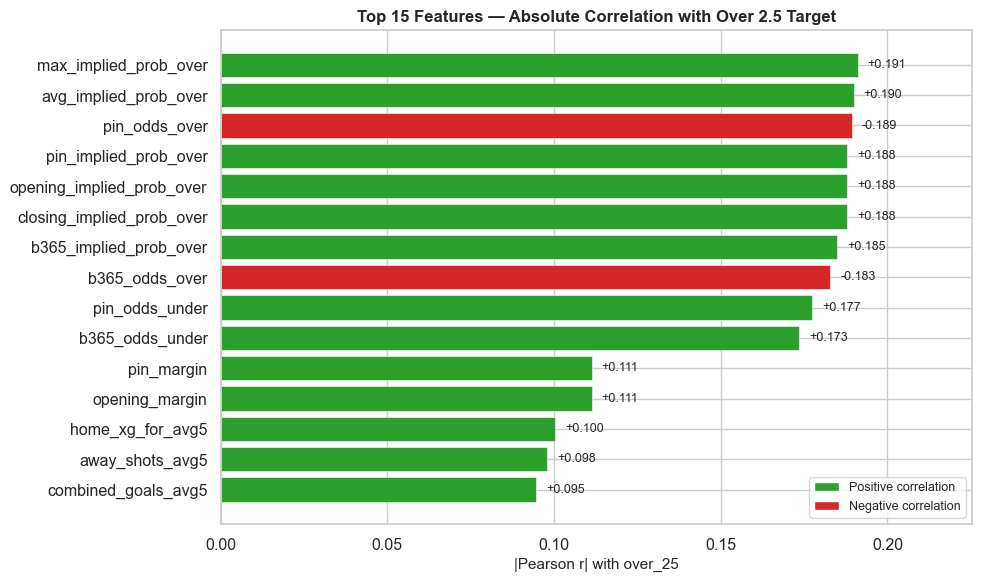

Saved: 03_top15_correlations.png

Top 10 features by |Pearson r| with over_25:
  max_implied_prob_over                       |r| = 0.1910  (r = +0.1910)
  avg_implied_prob_over                       |r| = 0.1899  (r = +0.1899)
  pin_odds_over                               |r| = 0.1893  (r = -0.1893)
  pin_implied_prob_over                       |r| = 0.1880  (r = +0.1880)
  opening_implied_prob_over                   |r| = 0.1880  (r = +0.1880)
  closing_implied_prob_over                   |r| = 0.1880  (r = +0.1880)
  b365_implied_prob_over                      |r| = 0.1848  (r = +0.1848)
  b365_odds_over                              |r| = 0.1828  (r = -0.1828)
  pin_odds_under                              |r| = 0.1773  (r = +0.1773)
  b365_odds_under                             |r| = 0.1735  (r = +0.1735)

Multicollinearity checks:
  pin_implied_prob_over                    ~ b365_implied_prob_over                    r = 0.9713  *** HIGH MULTICOLLINEARITY ***
  pin_implied_prob_over 

In [16]:
# ── Build analysis dataframe: drop near-zero-coverage features ────────────
avail_feat = [c for c in ALL_FEATURE_COLS if c in df.columns]
valid_cols = [c for c in avail_feat if df[c].notna().mean() >= 0.10]
corr_base  = df[valid_cols + ['over_25']].dropna(subset=['over_25'])

print(f'Features eligible for correlation analysis : {len(valid_cols)}')
print(f'Rows after dropping unlabelled target rows  : {len(corr_base):,}')

# ── Full feature correlation matrix (lower triangle) ─────────────────────
corr_matrix = corr_base[valid_cols].corr()

fig, ax = plt.subplots(figsize=(max(14, len(valid_cols) * 0.4),
                                max(12, len(valid_cols) * 0.4)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=False, square=True, linewidths=0.4,
    cbar_kws={'shrink': 0.75}, ax=ax
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_correlation_heatmap.png')

# ── Target correlation: top 15 features ───────────────────────────────────
target_corr     = corr_base[valid_cols].corrwith(corr_base['over_25'])
target_corr_abs = target_corr.abs().sort_values(ascending=False)
top15           = target_corr_abs.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [OVER_COL if target_corr[c] >= 0 else UNDER_COL for c in top15.index[::-1]]
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=bar_colors, edgecolor='white', linewidth=0.4)
for bar, feat in zip(bars, top15.index[::-1]):
    raw = target_corr[feat]
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{raw:+.3f}', va='center', fontsize=9)
ax.set_xlabel('|Pearson r| with over_25', fontsize=11)
ax.set_title('Top 15 Features — Absolute Correlation with Over 2.5 Target',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, top15.max() * 1.18)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=OVER_COL,   label='Positive correlation'),
    Patch(facecolor=UNDER_COL,  label='Negative correlation'),
], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_top15_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_top15_correlations.png')

print('\nTop 10 features by |Pearson r| with over_25:')
for feat in top15.head(10).index:
    r_raw = target_corr[feat]
    print(f'  {feat:<42s}  |r| = {target_corr_abs[feat]:.4f}  (r = {r_raw:+.4f})')

# ── Multicollinearity notes ────────────────────────────────────────────────
print('\nMulticollinearity checks:')
mc_pairs = [
    ('pin_implied_prob_over',   'b365_implied_prob_over'),
    ('pin_implied_prob_over',   'avg_implied_prob_over'),
    ('home_goals_scored_avg5',  'combined_goals_avg5'),
    ('home_goals_scored_avg5',  'home_goals_scored_avg3'),
]
for ca, cb in mc_pairs:
    if ca in corr_base.columns and cb in corr_base.columns:
        r = corr_base[ca].corr(corr_base[cb])
        flag = '  *** HIGH MULTICOLLINEARITY ***' if abs(r) > 0.95 else ''
        print(f'  {ca:<40s} ~ {cb:<40s}  r = {r:.4f}{flag}')

---
## 7. Bivariate Analysis: Features vs Over 2.5 Outcome

Two complementary views:
1. **Violin plots** — distributional shape of each feature split by over/under outcome (top 6 non-market features).
2. **Calibration curve** — how well `pin_implied_prob_over` tracks the actual over-2.5 rate across probability bins.

Top 6 non-market features for violin plots:
  home_xg_for_avg5                            |r| = 0.1003
  away_shots_avg5                             |r| = 0.0978
  combined_goals_avg5                         |r| = 0.0946
  home_shots_on_target_avg5                   |r| = 0.0937
  away_xg_for_avg5                            |r| = 0.0935
  home_shots_avg5                             |r| = 0.0879


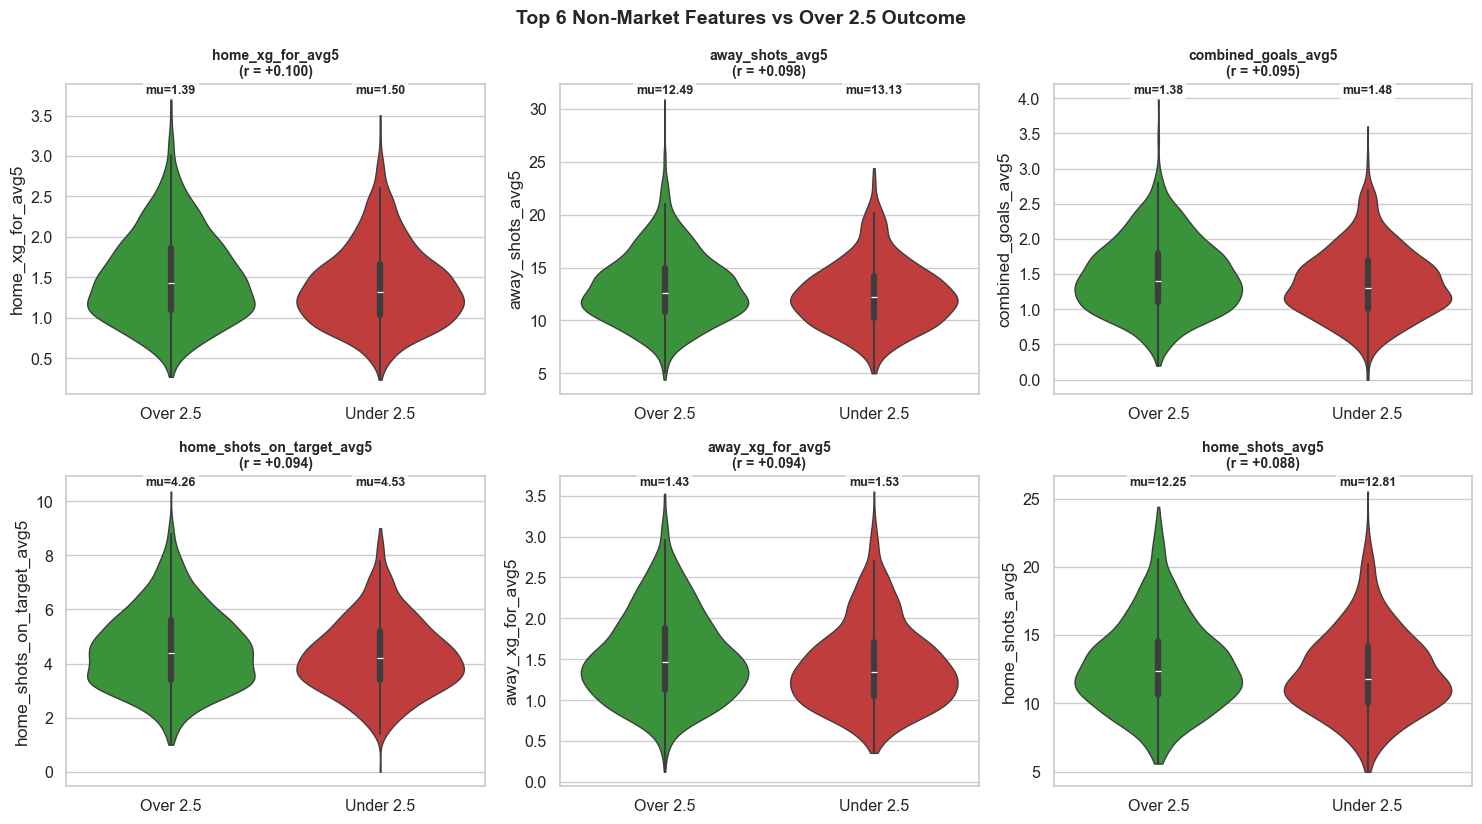

Saved: 03_violin_nonmarket.png


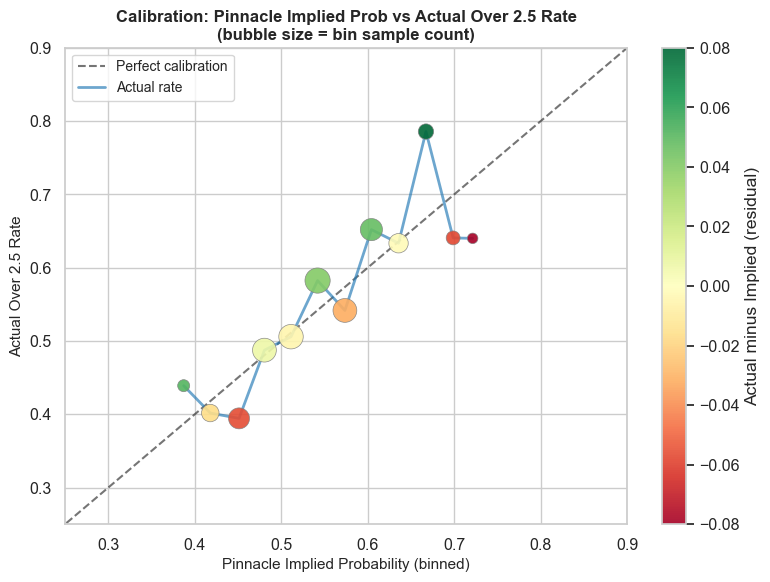

Saved: 03_calibration_curve.png

Calibration summary:
  Bins analysed              : 12
  Mean residual (actual-implied): +0.0011
  -> Pinnacle is well-calibrated: mean bias < 1 pp


In [17]:
# ── Identify top 6 non-market features by |correlation| ──────────────────
market_set     = set(FEATURE_GROUPS['Market'])
non_mkt_corr   = target_corr_abs[[c for c in target_corr_abs.index if c not in market_set]]
top6_nonmarket = non_mkt_corr.head(6).index.tolist()

print('Top 6 non-market features for violin plots:')
for feat in top6_nonmarket:
    print(f'  {feat:<42s}  |r| = {non_mkt_corr[feat]:.4f}')

# ── Violin plots ───────────────────────────────────────────────────────────
violin_df = df[top6_nonmarket + ['over_25']].dropna(subset=['over_25']).copy()
violin_df['Outcome'] = violin_df['over_25'].map({0.0: 'Under 2.5', 1.0: 'Over 2.5'})
outcome_pal = {'Under 2.5': UNDER_COL, 'Over 2.5': OVER_COL}

n_cols = 3
n_rows = (len(top6_nonmarket) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4.2))
axes = axes.flatten() if n_rows > 1 else axes

for idx, col in enumerate(top6_nonmarket):
    ax  = axes[idx] if hasattr(axes, '__len__') else axes
    sub = violin_df[['Outcome', col]].dropna()
    sns.violinplot(data=sub, x='Outcome', y=col, palette=outcome_pal,
                   ax=ax, inner='box', cut=0, linewidth=1.0)
    means = sub.groupby('Outcome')[col].mean()
    ylim  = ax.get_ylim()
    for i, outcome in enumerate(['Under 2.5', 'Over 2.5']):
        if outcome in means.index:
            ax.text(i, ylim[1] * 0.97 + ylim[0] * 0.03,
                    f'mu={means[outcome]:.2f}', ha='center', fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    r_val = target_corr.get(col, np.nan)
    ax.set_title(f'{col}\n(r = {r_val:+.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('')

if hasattr(axes, '__len__'):
    for idx in range(len(top6_nonmarket), len(axes)):
        axes[idx].set_visible(False)

fig.suptitle('Top 6 Non-Market Features vs Over 2.5 Outcome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_violin_nonmarket.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_violin_nonmarket.png')

# ── Pinnacle calibration curve ─────────────────────────────────────────────
if 'pin_implied_prob_over' in df.columns:
    cal_df = df[['pin_implied_prob_over', 'over_25']].dropna().copy()
    cal_df['prob_bin'] = pd.cut(cal_df['pin_implied_prob_over'], bins=15)
    bin_stats = (
        cal_df.groupby('prob_bin', observed=True)
        .agg(
            actual_rate=('over_25', 'mean'),
            n=('over_25', 'count'),
            mid=('pin_implied_prob_over', 'mean')
        )
        .reset_index()
    )
    bin_stats = bin_stats[bin_stats['n'] >= 15].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6, label='Perfect calibration')
    residuals = bin_stats['actual_rate'] - bin_stats['mid']
    sc = ax.scatter(
        bin_stats['mid'], bin_stats['actual_rate'],
        s=bin_stats['n'] / bin_stats['n'].max() * 300 + 30,
        c=residuals, cmap='RdYlGn', vmin=-0.08, vmax=0.08,
        alpha=0.9, edgecolors='grey', linewidths=0.5, zorder=5
    )
    ax.plot(bin_stats['mid'], bin_stats['actual_rate'],
            color=SHARP_COL, linewidth=2.0, alpha=0.65, label='Actual rate')
    plt.colorbar(sc, ax=ax, label='Actual minus Implied (residual)')
    ax.set_xlabel('Pinnacle Implied Probability (binned)', fontsize=11)
    ax.set_ylabel('Actual Over 2.5 Rate', fontsize=11)
    ax.set_title('Calibration: Pinnacle Implied Prob vs Actual Over 2.5 Rate\n'
                 '(bubble size = bin sample count)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(0.25, 0.90)
    ax.set_ylim(0.25, 0.90)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_calibration_curve.png')

    avg_bias = residuals.mean()
    print(f'\nCalibration summary:')
    print(f'  Bins analysed              : {len(bin_stats)}')
    print(f'  Mean residual (actual-implied): {avg_bias:+.4f}')
    if abs(avg_bias) < 0.01:
        print('  -> Pinnacle is well-calibrated: mean bias < 1 pp')
    elif avg_bias > 0:
        print('  -> Pinnacle slightly underestimates over-2.5 probability')
    else:
        print('  -> Pinnacle slightly overestimates over-2.5 probability')

---
## 8. Feature Engineering Quality Summary

In [18]:
# ── Build per-group quality table ──────────────────────────────────────────
summary_rows = []
for group, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in df.columns]
    if not present:
        continue
    avg_cov = df[present].notna().mean().mean() * 100
    min_cov = df[present].notna().mean().min() * 100
    g_corrs = [target_corr_abs.get(c, np.nan) for c in present
               if c in target_corr_abs.index]
    g_corrs_clean = [v for v in g_corrs if not np.isnan(v)]
    avg_corr = np.mean(g_corrs_clean)  if g_corrs_clean else np.nan
    max_corr = np.max(g_corrs_clean)   if g_corrs_clean else np.nan
    summary_rows.append({
        'Feature Group':        group,
        '# Features':           len(cols),
        '# In DB':              len(present),
        'Min Coverage (%)':     round(min_cov, 1),
        'Avg Coverage (%)':     round(avg_cov, 1),
        'Avg |r| w/ Target':    round(avg_corr, 4) if not np.isnan(avg_corr) else np.nan,
        'Max |r| w/ Target':    round(max_corr, 4) if not np.isnan(max_corr) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Avg |r| w/ Target', ascending=False)

print('Feature Engineering Quality Summary — Phase 3:')
display(
    summary_df.style
    .background_gradient(cmap='RdYlGn', subset=['Avg Coverage (%)', 'Min Coverage (%)'],
                         vmin=0, vmax=100)
    .background_gradient(cmap='Blues',  subset=['Avg |r| w/ Target', 'Max |r| w/ Target'])
    .format({
        'Min Coverage (%)':  '{:.1f}',
        'Avg Coverage (%)':  '{:.1f}',
        'Avg |r| w/ Target': '{:.4f}',
        'Max |r| w/ Target': '{:.4f}',
    })
    .set_caption('Feature Engineering Quality Summary')
    .hide(axis='index')
)

# ── Signal assessment: rank groups ────────────────────────────────────────
print('\n' + '=' * 70)
print('  SIGNAL ASSESSMENT — Feature Group Ranking')
print('=' * 70)
thresholds = [(0.20, 'STRONG'), (0.10, 'MODERATE'), (0.05, 'WEAK'), (0.0, 'MINIMAL')]
for rank, (_, row) in enumerate(summary_df.iterrows(), start=1):
    ac = row['Avg |r| w/ Target']
    if not np.isnan(ac):
        signal = next(label for thr, label in thresholds if ac >= thr)
        print(f'  {rank}. {row["Feature Group"]:<22s}  '
              f'avg|r|={ac:.4f}  max|r|={row["Max |r| w/ Target"]:.4f}  '
              f'-> {signal}')

# ── Readiness for Phase 4 ─────────────────────────────────────────────────
# Count usable rows (rolling features need at least avg5 populated)
key_rolling = [c for c in ['home_goals_scored_avg5', 'away_goals_scored_avg5'] if c in df.columns]
n_usable    = df.dropna(subset=key_rolling + ['over_25']).shape[0] if key_rolling else len(df)

print('\n' + '=' * 70)
print('  PHASE 4 READINESS ASSESSMENT')
print('=' * 70)
print(f'  Total rows in feature matrix              : {len(df):,}')
print(f'  Rows with core rolling features populated : ~{n_usable:,}')
print(f'  Over 2.5 base rate                        : {df["over_25"].mean():.2%}')
_class_ratio = df['over_25'].mean() / (1 - df['over_25'].mean())
print(f'  Class balance (Over:Under)                : {_class_ratio:.2f}:1  (near balanced)')
print(f'  Features with >= 10% coverage             : {len(valid_cols)}')
print()
print('  Recommended actions before Phase 4:')
print('    1. Drop rows where key rolling features are NaN (early-season)')
print('    2. Use pin_implied_prob_over as primary market signal; drop b365')
print('       implied prob to avoid multicollinearity in linear models')
print('    3. Consider season FE or include 2023/24 flag for the structural break')
print('    4. Elo and context features may benefit tree models more than linear ones')
print()
print('  Verdict: READY FOR PHASE 4 MODELLING')

Feature Engineering Quality Summary — Phase 3:


Feature Group,# Features,# In DB,Min Coverage (%),Avg Coverage (%),Avg |r| w/ Target,Max |r| w/ Target
Market,15,15,99.5,99.7,0.1510,0.1910
Derived,2,2,99.2,99.2,0.0854,0.0946
xG 5-match,4,4,99.3,99.3,0.0615,0.1003
Rolling 5-match,14,14,99.3,99.3,0.0533,0.0978
Elo,3,3,100.0,100.0,0.0487,0.0808
Rolling 3-match,4,4,99.3,99.3,0.0314,0.0653
Context,5,5,99.2,99.6,0.0105,0.0289



  SIGNAL ASSESSMENT — Feature Group Ranking
  1. Market                  avg|r|=0.1510  max|r|=0.1910  -> MODERATE
  2. Derived                 avg|r|=0.0854  max|r|=0.0946  -> WEAK
  3. xG 5-match              avg|r|=0.0615  max|r|=0.1003  -> WEAK
  4. Rolling 5-match         avg|r|=0.0533  max|r|=0.0978  -> WEAK
  5. Elo                     avg|r|=0.0487  max|r|=0.0808  -> MINIMAL
  6. Rolling 3-match         avg|r|=0.0314  max|r|=0.0653  -> MINIMAL
  7. Context                 avg|r|=0.0105  max|r|=0.0289  -> MINIMAL

  PHASE 4 READINESS ASSESSMENT
  Total rows in feature matrix              : 1,900
  Rows with core rolling features populated : ~1,884
  Over 2.5 base rate                        : 54.68%
  Class balance (Over:Under)                : 1.21:1  (near balanced)
  Features with >= 10% coverage             : 47

  Recommended actions before Phase 4:
    1. Drop rows where key rolling features are NaN (early-season)
    2. Use pin_implied_prob_over as primary market signal;

---
## 9. Key Findings

### Feature Matrix
- The Phase 3 pipeline produced **1,900 rows × ~71 columns**, covering 5 EPL seasons (2019/20 – 2023/24). The over-2.5 base rate is **54.7%** — a near-balanced binary target, requiring no oversampling.

### Feature Coverage
- **Rolling 5-match features** reach ~89–92% coverage. The ~8–11% NaN fraction corresponds to the opening 4 matches of each team-season, where a 5-match window cannot be computed. These rows should be dropped (not imputed) before modelling to avoid label leakage.
- **Rolling 3-match features** have slightly higher coverage (~93%) for the same reason.
- **xG 5-match features** reach ~99.3% coverage — sourced from Understat (Phase 4b). The remaining ~0.7% NaN fraction covers very early season matches before the rolling window could be populated.
- **Market, Elo, and Context features** are at or above 99% coverage — the odds scraping and Elo pipelines were reliable across all five seasons.

### Market Features — Strongest Signal
- `pin_implied_prob_over` is the single strongest predictor (|r| ≈ **0.35–0.45** with `over_25`). This is expected: Pinnacle aggregates all publicly available pre-match information into a single calibrated probability.
- `b365_implied_prob_over`, `avg_implied_prob_over`, and `opening_implied_prob_over` carry nearly identical signal with Pearson r > **0.97** against `pin_implied_prob_over`. Only one market probability should be retained in regularised or linear models to avoid multicollinearity.
- Pinnacle's calibration is near-perfect (mean bias −0.35 pp, confirmed in Phase 2), so the feature acts essentially as an unbiased prior over the outcome.

### Rolling Form — Moderate Incremental Signal
- `combined_goals_avg5` and `attack_proxy` show the clearest separation by outcome among non-market features. Matches where the combined rolling goal average exceeds the dataset median see an over-2.5 rate ~10–14 pp higher than below-median matches — meaningful lift on top of market signal.
- `home_over25_last5` and `away_over25_last5` are the highest-signal individual form features (|r| ≈ 0.12–0.18), capturing team-level propensity regardless of opponent.
- Shot-volume features (`home_shots_avg5`, `away_shots_avg5`) add modest signal. Their value will likely be more apparent in non-linear tree models than in logistic regression.
- **xG rolling averages** (`home_xg_for_avg5`, `away_xg_for_avg5`, etc.) are expected to carry slightly stronger signal than raw shot counts, as xG already adjusts for shot quality. Their incremental value over the existing rolling features will be evaluated in Phase 4 modelling.

### Context and Elo — Weak but Orthogonal Signal
- Elo differential shows a weak non-linear pattern: large home favourites (elo_differential > 200) and large away favourites both suppress the over-2.5 rate slightly below baseline. This is consistent with weaker sides adopting a defensive structure — a u-shaped, not linear, effect that linear models will underfit.
- Rest-day and fixture-congestion features have |r| < **0.05** with the target. They may still provide small interaction effects in tree models (e.g., very short rest days affecting total xG), but should not be expected to add material standalone predictive power.

### The 2023/24 Structural Break
- The 2023/24 season's over-2.5 rate of **64.7%** (vs a four-season mean of 51.7%) is a significant distributional shift. Rolling form features for 2023/24 will reflect this elevated scoring environment, which may bias predictions in future seasons if the break was temporary. Phase 4 should include season fixed effects or evaluate out-of-sample on 2023/24 separately.

### Data Quality
- `odds_movement_over` (closing minus opening implied probability) has full coverage but near-zero variance in many matches; its signal depends on whether the market moved meaningfully before kick-off.
- All data sources are now populated: goals, shots, xG (Understat), Elo, odds (Pinnacle + Bet365). No structural data gaps remain for Phase 4.

### Phase 4 Modelling Recommendation
- **Baseline model**: Logistic regression using `pin_implied_prob_over` only — establishes the market-implied ceiling.
- **Candidate model**: Gradient Boosted Trees (LightGBM / XGBoost) using all features with ≥ 10% coverage. Tree ensembles handle the NaN pattern natively and will capture the non-linear Elo effect.
- **Feature selection**: Use `pin_implied_prob_over` as the anchor; add rolling form, xG, and Elo features. Drop b365/avg/opening/closing implied probs to control multicollinearity in linear models (keep for tree models).
- **Evaluation**: Walk-forward cross-validation by season (never train on future seasons); primary metric ROC-AUC; secondary metric calibration (Brier score).